# How AI Coding Agents Fix Bugs Over Time

This notebook follows up on our MSR '26 paper, *"Understanding the Rejection of Fixes Generated by Agentic Pull Requests."*
That paper looked at a single snapshot. Here we add **time** and ask how things change month by month, using the
[GitHub-Agentic-PR-Dataset](https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset).

**The data:** 422,618 bug-fix pull requests (PRs) from Dec 2024 to Feb 2026 (15 months).
121,832 were made by AI agents (Claude_Code, Cursor, Copilot, Devin) and 300,786 by humans.

**The questions we answer:**
- Does the share of fixes that get rejected change over time? (RQ1a)
- Do fixes get bigger or smaller over time? (RQ1b)
- Do people change which agent they use to fix bugs? (RQ2a)
- When an agent's fix is rejected, does switching to another agent help? (RQ2b)
- Once merged, do agent fixes stay, or get undone? (RQ4)
- Which kinds of bugs are agents good or bad at? (RQ5)
- Does adding a test make a fix more likely to be accepted? (RQ6)

## A few simple definitions

- **Month** — the month a PR was created.
- **Rejected** — the PR was closed without being merged.
- **Merged** — the PR was accepted into the project.
- **Rejection rate** — among the PRs that were *decided* (merged or closed), the share that were rejected.
  We leave out PRs that are still open, since we don't know their outcome yet.
- **Code churn** — how many lines a fix adds and removes (a simple measure of fix size).
- **Has a test** — the PR changed at least one test file.

**Fair comparison (important):** agents and humans don't work on the same projects, so we compare them only inside the
**1,218 repositories that contain both agent and human fixes**. All agent-vs-human results (RQ1a, RQ1b, RQ4, RQ5, RQ6)
use this **matched** set, so any difference is about agent vs human, not about different projects.
RQ2a and RQ2b look only at agents, so they use all the data.

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, chi2_contingency
%matplotlib inline
warnings.filterwarnings("ignore")

BASE = r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes"
DATA = os.path.join(BASE, "data")
AGENTS = ["Claude_Code", "Cursor", "Copilot", "Devin"]

prs = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"),
                      columns=["id","state","created_at","merged_at","repo_id","is_agent","agent"])
prs["month"] = prs["created_at"].str.slice(0, 7)
prs = prs[prs["month"].notna() & (prs["month"] != "")]
prs["closed"]   = prs["state"] == "closed"
mna             = prs["merged_at"].isna() | prs["merged_at"].astype(str).isin(["", "NaT", "None"])
prs["merged"]   = ~mna
prs["rejected"] = prs["closed"] & ~prs["merged"]
prs["grp"]      = np.where(prs["is_agent"], "Agent", "Human")
months = sorted(prs["month"].unique())
xi = np.arange(len(months))

# matched set: repos that have BOTH agent and human fixes (for fair comparison)
A = set(prs.loc[prs.is_agent, "repo_id"]); H = set(prs.loc[~prs.is_agent, "repo_id"])
MATCHED_REPOS = A & H
prs["matched"] = prs["repo_id"].isin(MATCHED_REPOS)
print(f"{len(prs):,} fix PRs | {months[0]}..{months[-1]} ({len(months)} months)")
print(f"matched repos (both agent & human): {len(MATCHED_REPOS):,} | "
      f"matched PRs: agent={int((prs.matched & prs.is_agent).sum()):,} human={int((prs.matched & ~prs.is_agent).sum()):,}")

## First, a fairness check — why we compare inside shared repos

Before comparing agents and humans, we check whether the *type of project* matters. We split the fixes four ways:
agent vs human, and shared repos (have both kinds) vs single-type repos (only one kind).

**It matters a lot.** In **shared** repos, agent fixes are rejected **18.1%** and human fixes **15.1%**. But in
**single-type** repos — mostly small/solo projects that merge almost everything — both are lower (agent 14.7%, human 10.9%).
So the project, not just who wrote the fix, drives a big part of the rejection rate. That's exactly why, for a fair
agent-vs-human comparison, we use only the **shared repos** from here on.

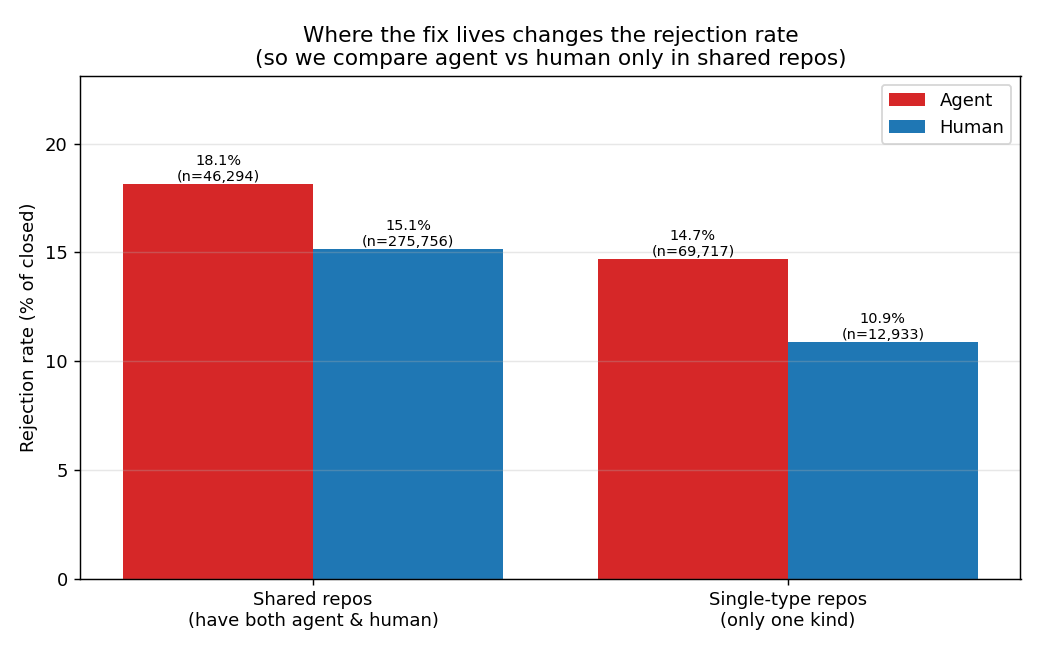

In [ ]:
def rr(mask):
    d = prs[mask & prs["closed"]]; return 100 * d["rejected"].mean(), len(d)
a_sh, na_sh = rr(prs.is_agent & prs.matched);   a_so, na_so = rr(prs.is_agent & ~prs.matched)
h_sh, nh_sh = rr(~prs.is_agent & prs.matched);  h_so, nh_so = rr(~prs.is_agent & ~prs.matched)
print(f"Agent  shared {a_sh:.1f}% (n={na_sh:,}) | single-type {a_so:.1f}% (n={na_so:,})")
print(f"Human  shared {h_sh:.1f}% (n={nh_sh:,}) | single-type {h_so:.1f}% (n={nh_so:,})")

x = np.arange(2)
plt.figure(figsize=(8,5))
b1 = plt.bar(x-0.2, [a_sh, a_so], width=0.4, label="Agent", color="#d62728")
b2 = plt.bar(x+0.2, [h_sh, h_so], width=0.4, label="Human", color="#1f77b4")
for bars, ns in [(b1,[na_sh,na_so]), (b2,[nh_sh,nh_so])]:
    for bar, n in zip(bars, ns):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{bar.get_height():.1f}%\n(n={n:,})",
                 ha="center", va="bottom", fontsize=8)
plt.xticks(x, ["Shared repos\n(have both agent & human)", "Single-type repos\n(only one kind)"])
plt.ylabel("Rejection rate (% of closed)")
plt.title("Where the fix lives changes the rejection rate\n(so we compare agent vs human only in shared repos)")
plt.ylim(0, max(a_sh,a_so,h_sh,h_so)+5); plt.legend(); plt.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## RQ1a — Does the rejection rate change over time? *(matched repos)*

**In short: inside the same projects, agent fixes are rejected a bit more than human fixes.** Overall it is about
**18% for agents vs 15% for humans** (a ~3-point gap). Both rise over the year, and the agent line sits clearly above
the human line for most of 2025 — so agents have *not* fully caught up to humans on equal ground.

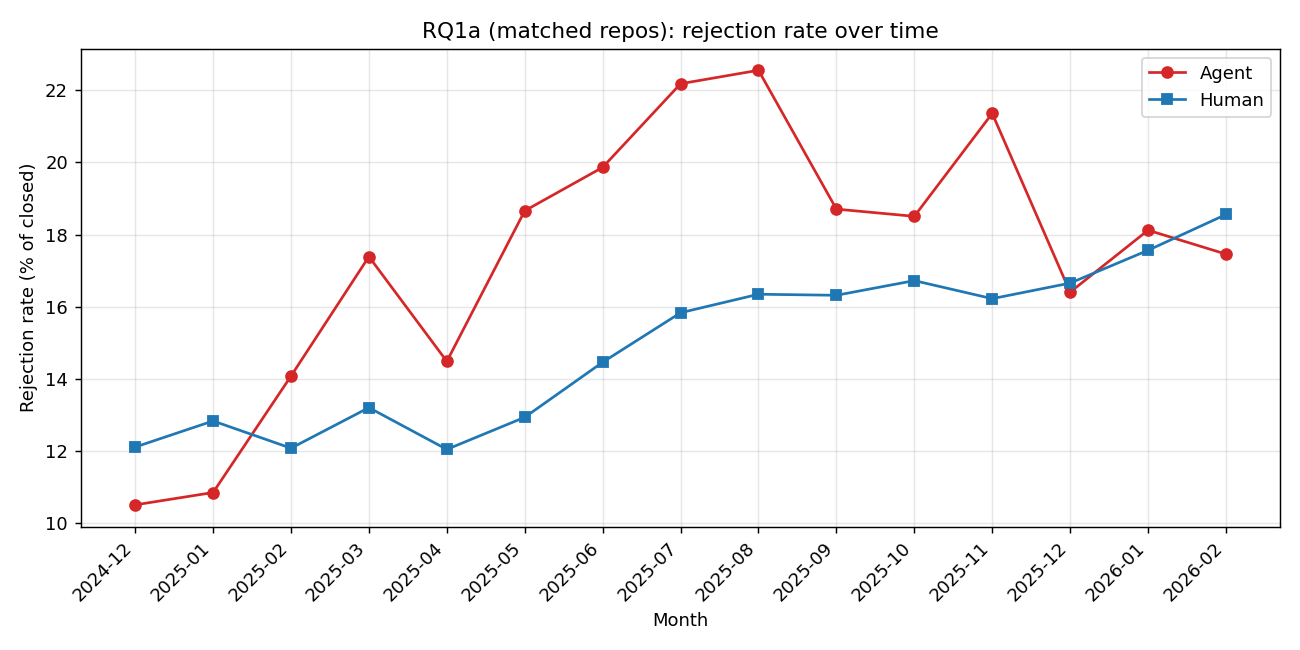

In [ ]:
M = prs[prs.matched]
def monthly_rate(df):
    g = df[df["closed"]].groupby("month")
    return (100 * g["rejected"].sum() / g["rejected"].count()).reindex(months)

agent_rej = monthly_rate(M[M.grp == "Agent"])
human_rej = monthly_rate(M[M.grp == "Human"])
ao = 100*M[M.is_agent & M.closed]["rejected"].mean(); ho = 100*M[~M.is_agent & M.closed]["rejected"].mean()
print(f"overall (matched): agent={ao:.1f}%  human={ho:.1f}%  gap={ao-ho:+.1f}pts")

plt.figure(figsize=(10, 5))
plt.plot(months, agent_rej.values, "o-", label="Agent", color="#d62728")
plt.plot(months, human_rej.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("Rejection rate (% of closed)"); plt.xlabel("Month (PR created)")
plt.title("RQ1a (matched repos): rejection rate over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ2a — Do people switch which agent they use to fix bugs? *(all agents)*

**In short: yes, a lot.** Claude_Code and Cursor were used for almost all agent fixes at the start
(about 90% in December 2024). Copilot was barely used until May 2025, then jumped to around 30% (when its coding
agent launched). Devin started strong but faded from a 27% peak down to about 5%.

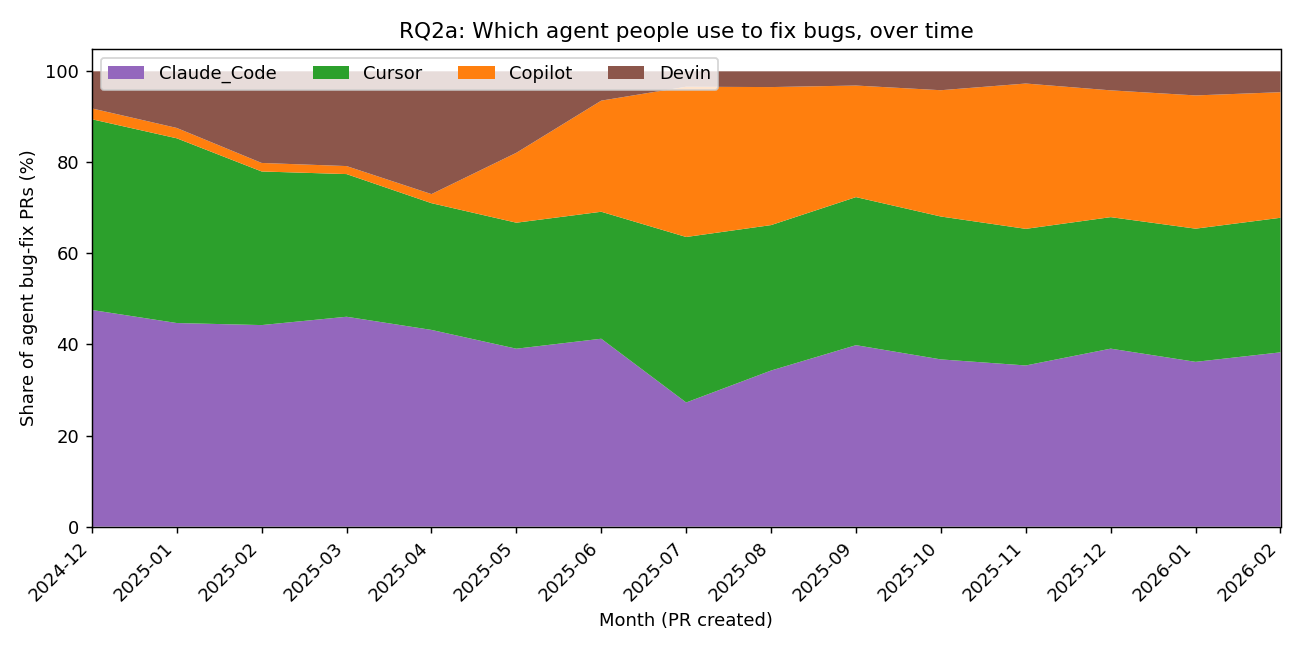

In [ ]:
agt = prs[prs.is_agent]
piv = agt[agt.agent.isin(AGENTS)].pivot_table(index="month", columns="agent",
        values="id", aggfunc="count", fill_value=0).reindex(months).fillna(0)
share = piv.div(piv.sum(axis=1), axis=0) * 100
for a in AGENTS:
    print(f"{a:12s}: {share[a].iloc[0]:4.0f}% -> {share[a].iloc[-1]:4.0f}%  (peak {share[a].max():.0f}% in {share[a].idxmax()})")

plt.figure(figsize=(10, 5))
plt.stackplot(months, [share[a].values for a in AGENTS], labels=AGENTS,
              colors=["#9467bd", "#2ca02c", "#ff7f0e", "#8c564b"])
plt.ylabel("Share of agent bug-fix PRs (%)"); plt.xlabel("Month (PR created)")
plt.title("RQ2a: Which agent people use to fix bugs, over time")
plt.xticks(rotation=45, ha="right"); plt.legend(loc="upper left", ncol=4); plt.margins(x=0)
plt.tight_layout(); plt.show()

## Loading the file-level changes (for fix size and tests)

The next table lists every file changed in each fix. We use it to measure how big each fix is (code churn)
and whether the fix touched a test file. PRs with no file rows are left out of the size numbers.

In [ ]:
det = pd.read_parquet(os.path.join(DATA, "fix_pr_commit_details.parquet"),
                      columns=["pr_id", "filename", "additions", "deletions"])
det["lines"] = det["additions"].fillna(0) + det["deletions"].fillna(0)
churn = det.groupby("pr_id")["lines"].sum().rename("churn")

TEST_RE = re.compile(r"(^|/)(tests?|__tests__|spec)(/|\.)|(_test\.|test_|\.test\.|\.spec\.|_spec\.|\.tests\.)", re.I)
det["is_test"] = det["filename"].fillna("").map(lambda f: bool(TEST_RE.search(f)))
has_test = det.groupby("pr_id")["is_test"].any().rename("has_test")

prs = prs.merge(churn, left_on="id", right_index=True, how="left")     # churn stays NaN if no file rows (covered-only)
prs = prs.merge(has_test, left_on="id", right_index=True, how="left")
prs["has_test"] = prs["has_test"].fillna(False).astype(bool)
print(f"file-level coverage: {prs['churn'].notna().mean()*100:.1f}% of fix PRs have file rows")

## RQ1b — Do fixes get bigger or smaller over time? *(matched repos)*

**In short:** agent fixes are still a bit bigger than human fixes (a typical agent fix changes about **44 lines**, a
human one about **33**), but inside the same projects the difference is small. Agent fix size grew into mid-2025 and
then came back down — agents seem to write tighter fixes more recently.

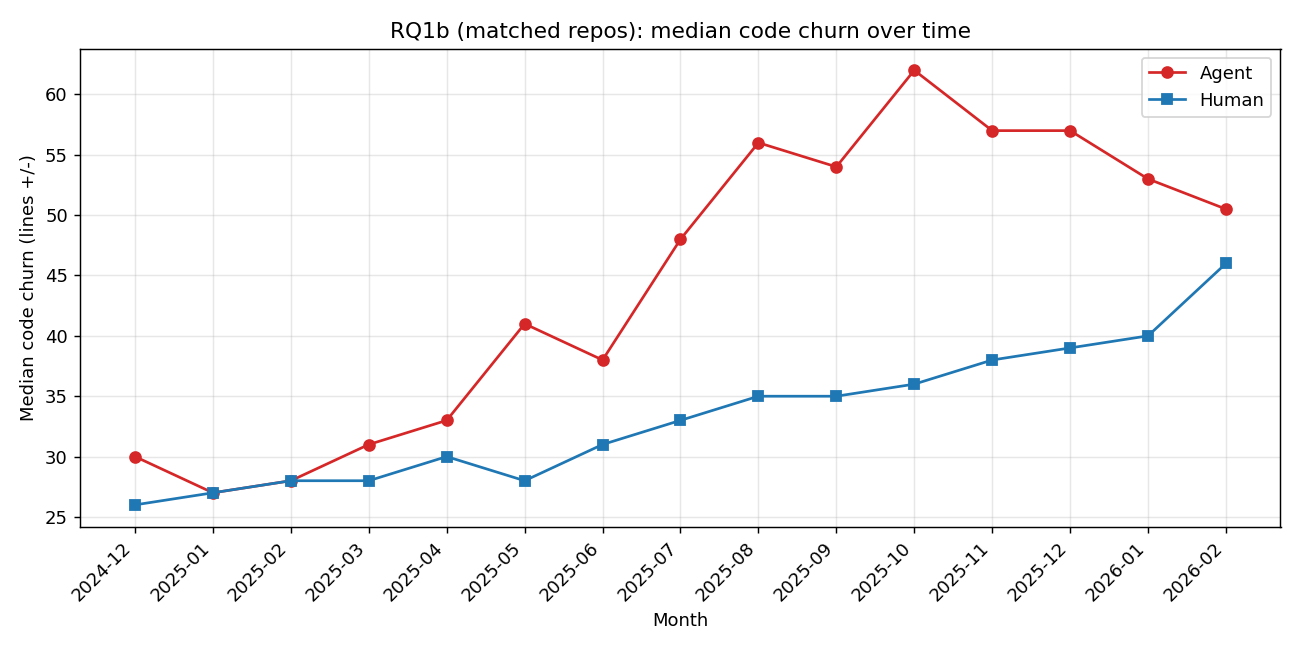

In [ ]:
M = prs[prs.matched]
def med_churn(df): return df.groupby("month")["churn"].median().reindex(months)
agent_ch, human_ch = med_churn(M[M.grp=="Agent"]), med_churn(M[M.grp=="Human"])
print(f"overall median churn (matched, covered): agent={M[M.is_agent].churn.median():.0f} | human={M[~M.is_agent].churn.median():.0f}")

plt.figure(figsize=(10, 5))
plt.plot(months, agent_ch.values, "o-", label="Agent", color="#d62728")
plt.plot(months, human_ch.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("Median code churn (lines +/-)"); plt.xlabel("Month (PR created)")
plt.title("RQ1b (matched repos): median code churn over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ6 — Does adding a test make a fix more likely to be accepted? *(matched repos)*

**In short: surprisingly, no — it's the other way around, and it's stronger for agents.** Inside the same projects,
agent fixes that include a test are rejected **about 5 points more** (22% vs 17%); for humans the gap is smaller
(about 2 points). A likely reason: fixes with tests are bigger and harder to review, and tests can expose failures.
We double-check the size explanation further down.

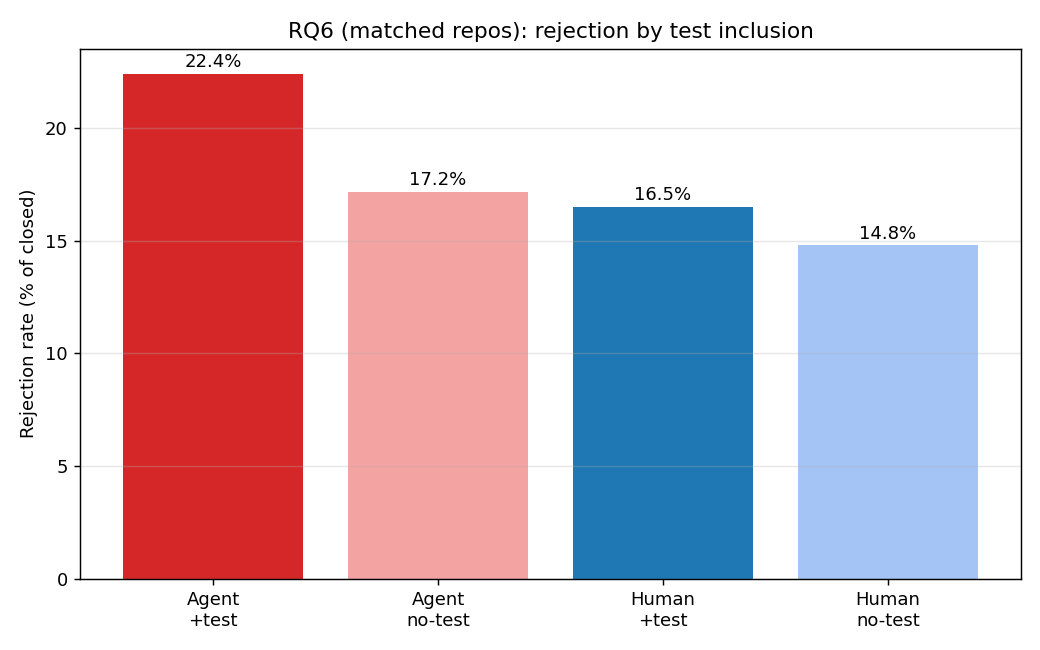

In [ ]:
M = prs[prs.matched]
def rej_rate(df):
    d = df[df.closed]; return (100 * d["rejected"].mean(), len(d))

rows = []
for g in ["Agent", "Human"]:
    sub = M[M.grp == g]
    rt, nt = rej_rate(sub[sub.has_test]); rn, nn = rej_rate(sub[~sub.has_test])
    c = sub[sub.closed]; _, p, _, _ = chi2_contingency(pd.crosstab(c.has_test, c.rejected))
    rows.append((g, rt, nt, rn, nn, p))
    print(f"{g}: +test {rt:.1f}% (n={nt:,}) | no-test {rn:.1f}% (n={nn:,}) | diff {rt-rn:+.1f}pts | chi2 p={p:.2e}")

labels = ["Agent\n+test", "Agent\nno-test", "Human\n+test", "Human\nno-test"]
vals = [rows[0][1], rows[0][3], rows[1][1], rows[1][3]]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, vals, color=["#d62728", "#f4a3a3", "#1f77b4", "#a3c4f4"])
for b, v in zip(bars, vals): plt.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}%", ha="center")
plt.ylabel("Rejection rate (% of closed)"); plt.title("RQ6 (matched repos): rejection by test inclusion")
plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

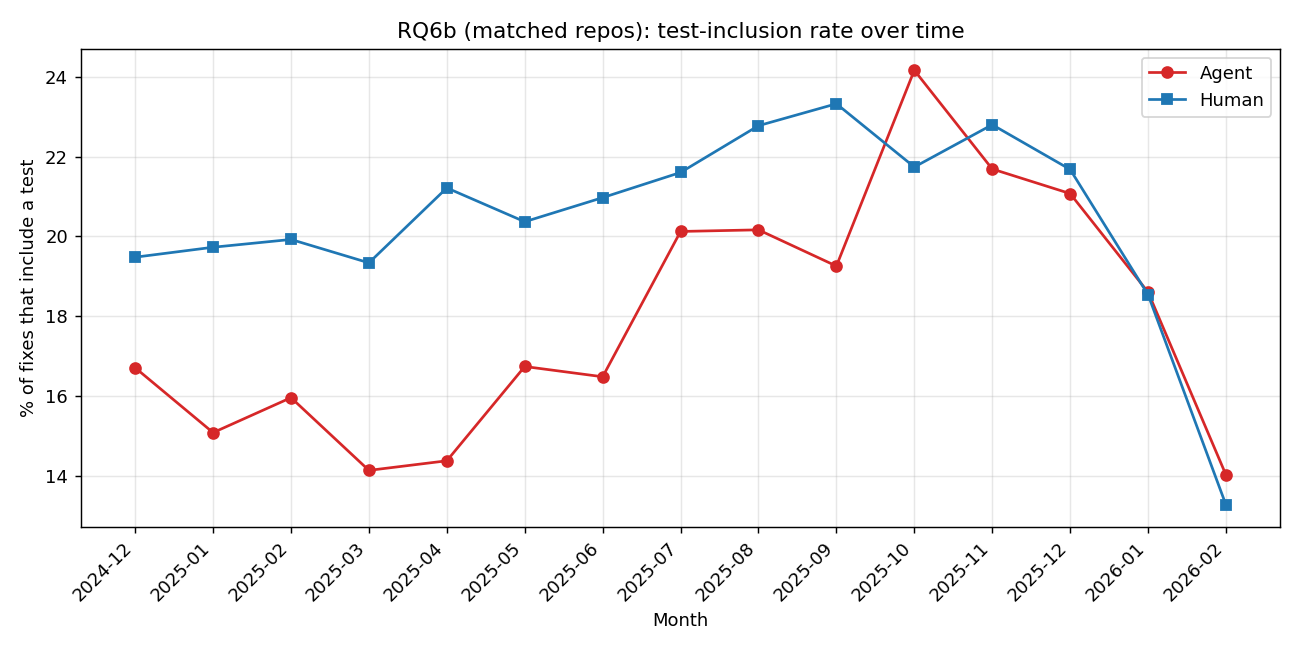

In [ ]:
M = prs[prs.matched]
ti_a = M[M.grp=="Agent"].groupby("month")["has_test"].mean().reindex(months)*100
ti_h = M[M.grp=="Human"].groupby("month")["has_test"].mean().reindex(months)*100
plt.figure(figsize=(10, 5))
plt.plot(months, ti_a.values, "o-", label="Agent", color="#d62728")
plt.plot(months, ti_h.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("% of bug-fix PRs that include a test"); plt.xlabel("Month (PR created)")
plt.title("RQ6b (matched repos): test-inclusion rate over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ2b — When an agent's fix is rejected, does switching to another agent help? *(all agents)*

We match fixes to the issue they say they close (for example "fixes #123") and group all the fixes aimed at the same
issue. About 18% of fixes mention an issue this way, and 6,311 issues got two or more fix attempts.

**In short: switching agents almost never happens.** Out of 653 issues where the first agent fix was rejected,
about 70% were eventually fixed — but mostly by retrying the *same* agent (45%) or by a person taking over (23%).
A *different* agent fixing it happened only 1.8% of the time (12 cases). So "just try a better model" is rare in practice.

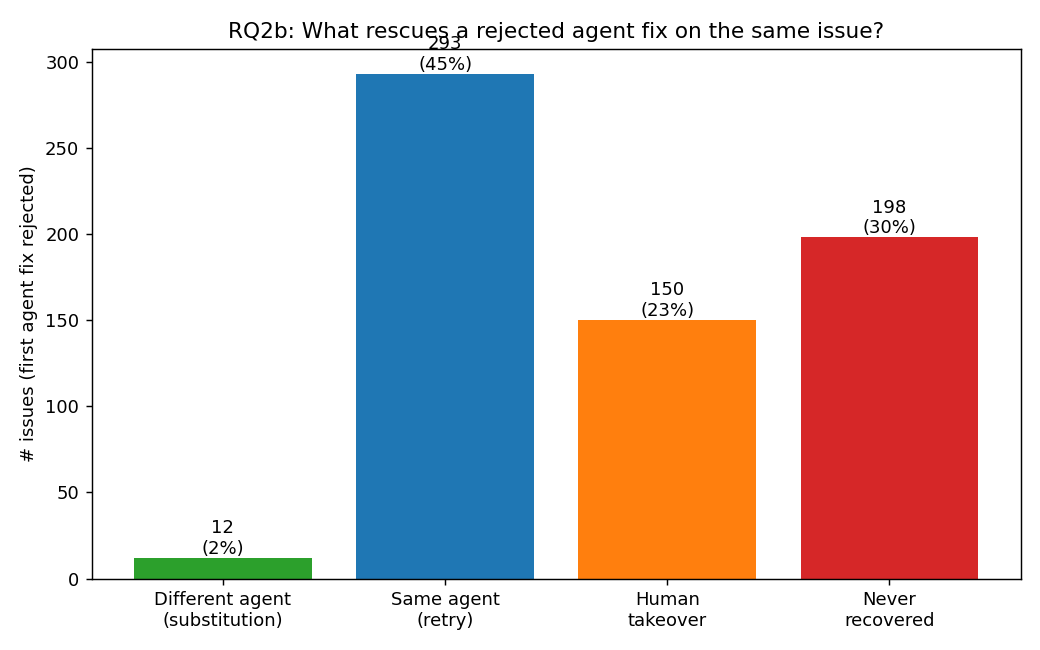

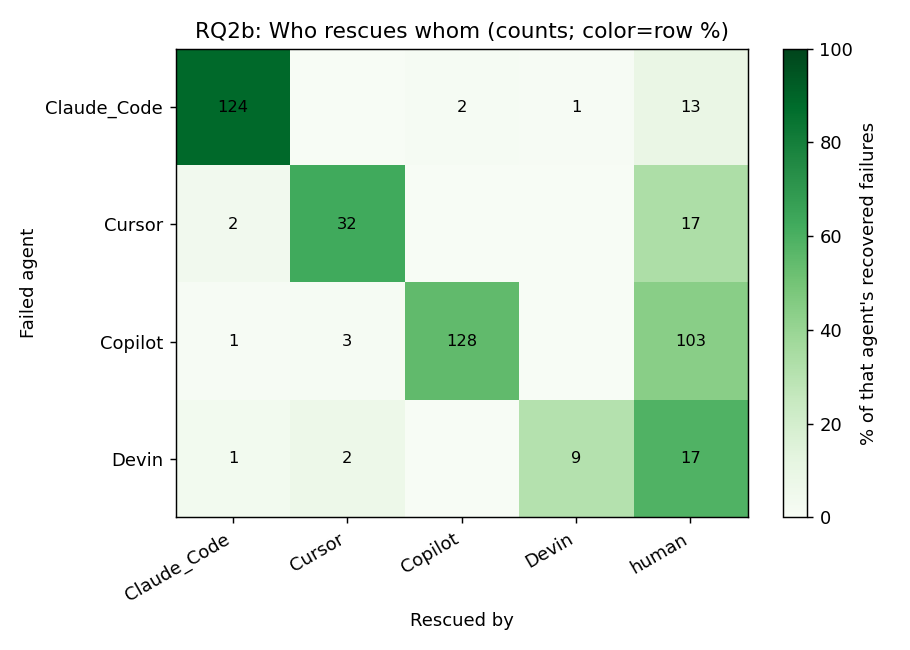

In [ ]:
rel = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"),
        columns=["id","title","body","state","created_at","merged_at","repo_id","is_agent","agent"])
_mna = rel["merged_at"].isna() | rel["merged_at"].astype(str).isin(["", "NaT", "None"])
rel["merged"]   = ~_mna
rel["rejected"] = (rel["state"] == "closed") & ~rel["merged"]
rel["label"]    = np.where(rel["is_agent"], rel["agent"], "human")
RESCUERS = AGENTS + ["human"]

KEY = re.compile(r"(?:close[sd]?|fix(?:e[sd])?|resolve[sd]?)\s*:?\s+#(\d+)", re.I)
rel["refs"] = [set(int(m) for m in KEY.findall(f"{t or ''}\n{b or ''}"))
               for t, b in zip(rel["title"], rel["body"])]
cov = (rel["refs"].map(len) > 0).mean() * 100

recs = [(r.repo_id, iss, r.created_at, r.label, r.is_agent, r.merged, r.rejected)
        for r in rel.itertuples(index=False) for iss in r.refs]
ex = pd.DataFrame(recs, columns=["repo_id","issue","created_at","label","is_agent","merged","rejected"]).sort_values("created_at")
g = ex.groupby(["repo_id","issue"]); sizes = g.size(); multi = sizes[sizes >= 2].index
print(f"{cov:.1f}% of fix PRs reference an issue | {len(multi):,} issues with >=2 fix attempts")

same = diff = human = norec = n_failed = 0
matrix = pd.DataFrame(0, index=AGENTS, columns=RESCUERS)
for key in multi:
    sub = g.get_group(key); first = sub.iloc[0]
    if not (first.is_agent and first.rejected): continue
    n_failed += 1; later = sub.iloc[1:]; win = later[later["merged"]]
    if len(win) == 0: norec += 1; continue
    resc = win.iloc[0]["label"]
    if resc == first.label: same += 1
    elif resc == "human":   human += 1
    else:                   diff += 1
    if first.label in AGENTS: matrix.loc[first.label, resc] += 1
rec = same + diff + human
print(f"first agent fix rejected: {n_failed} | recovered {100*rec/n_failed:.1f}% | "
      f"substitution {diff}, retry {same}, human {human}, never {norec}")

labels = ["Different agent\n(substitution)","Same agent\n(retry)","Human\ntakeover","Never\nrecovered"]
vals = [diff, same, human, norec]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, vals, color=["#2ca02c","#1f77b4","#ff7f0e","#d62728"])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v, f"{v}\n({100*v/n_failed:.0f}%)", ha="center", va="bottom")
plt.ylabel("# issues (first agent fix rejected)"); plt.title("RQ2b: What rescues a rejected agent fix?")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.imshow(matrix.values, cmap="Greens", aspect="auto")
plt.xticks(range(len(RESCUERS)), RESCUERS, rotation=30, ha="right"); plt.yticks(range(len(AGENTS)), AGENTS)
for i in range(len(AGENTS)):
    for j in range(len(RESCUERS)):
        if matrix.values[i,j]: plt.text(j, i, matrix.values[i,j], ha="center", va="center")
plt.xlabel("Rescued by"); plt.ylabel("Failed agent"); plt.title("RQ2b: Who rescues whom (counts)")
plt.colorbar(label="count"); plt.tight_layout(); plt.show()

## RQ4 — Once merged, do agent fixes stay, or get undone? *(matched repos)*

We look for commits that say "This reverts commit ..." and check whether they undo a merged fix.

**In short: agent fixes get undone less often than human fixes**, even inside the same projects (**0.07% vs 0.13%**).
Reverts are rare for everyone, so most fixes stay in place. *Note:* we only see reverts that go through PRs, so this is a lower bound.

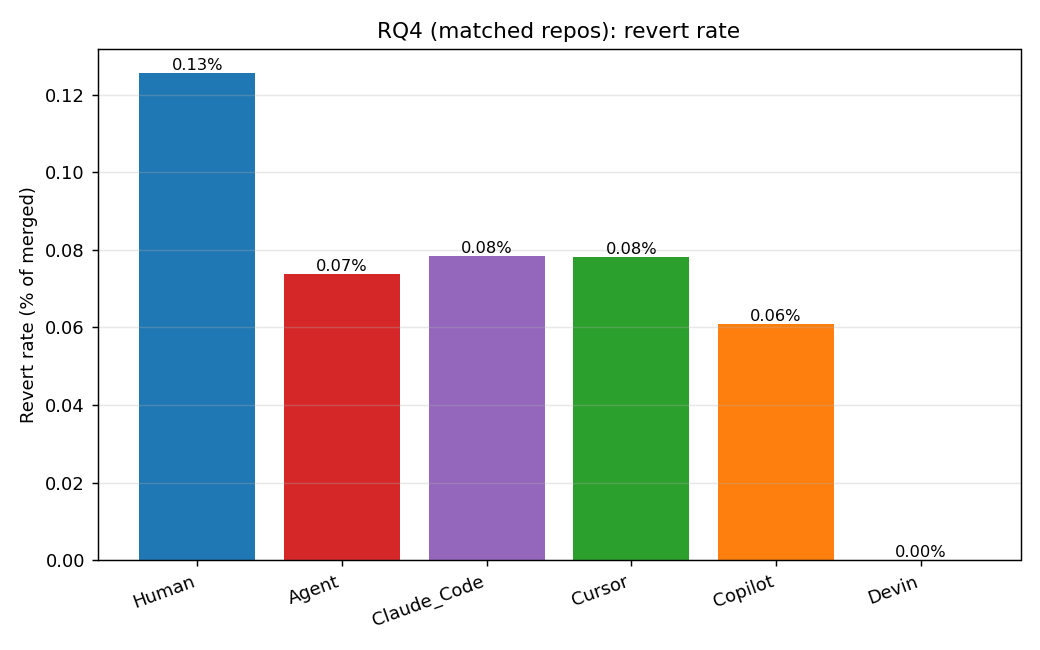

In [ ]:
fix_ids = set(rel["id"].tolist())
com = pd.read_parquet(os.path.join(DATA, "pr_commits.parquet"), columns=["sha","pr_id","message"])
fixcom = com[com["pr_id"].isin(fix_ids)]
sha_to_pr = dict(zip(fixcom["sha"].str.slice(0, 12), fixcom["pr_id"]))

REV = re.compile(r"reverts commit ([0-9a-f]{7,40})", re.I)
reverted_pr = {}
for pr_id, msg in zip(com["pr_id"], com["message"]):
    if not isinstance(msg, str) or "revert" not in msg.lower(): continue
    for ref in REV.findall(msg):
        orig = sha_to_pr.get(ref[:12])
        if orig is not None and orig != pr_id:
            reverted_pr.setdefault(orig, pr_id)
rev_ids = set(reverted_pr)

# matched repos only
merged = rel[rel["merged"] & rel["repo_id"].isin(MATCHED_REPOS)].copy()
merged["reverted"] = merged["id"].isin(rev_ids)
def rate(df): return (100*df["reverted"].mean(), int(df["reverted"].sum()), len(df))
ra, na, ta = rate(merged[merged.is_agent]); rh, nh, th = rate(merged[~merged.is_agent])
per_agent = {a: rate(merged[merged.agent == a]) for a in AGENTS}
print(f"Agent reverted {na}/{ta} = {ra:.3f}% | Human {nh}/{th} = {rh:.3f}%")
for a,(r,n,t) in per_agent.items(): print(f"  {a}: {n}/{t} = {r:.3f}%")

labels = ["Human","Agent (all)"] + AGENTS
vals = [rh, ra] + [per_agent[a][0] for a in AGENTS]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, vals, color=["#1f77b4","#d62728","#9467bd","#2ca02c","#ff7f0e","#8c564b"])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.ylabel("Revert rate (% of merged fixes)"); plt.title("RQ4 (matched repos): merged bug-fix revert rate")
plt.xticks(rotation=20, ha="right"); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## RQ5 — Which kinds of bugs are agents good or bad at? *(matched repos)*

We sort each fix into a bug type using words in its title and description, then compare rejection rates.

**In short: agents do worst on the hard, high-stakes bugs.** Inside the same projects, the agent–human gap is largest for
**concurrency (+10 points)**, **type errors (+9)**, and **security (+7)** — these are also where agent fixes are rejected most
(27–30%). On simple things like **typos/docs**, agents are actually accepted slightly *more* than humans. So agents shine on
easy fixes and struggle on the bugs that need deep understanding of the code.

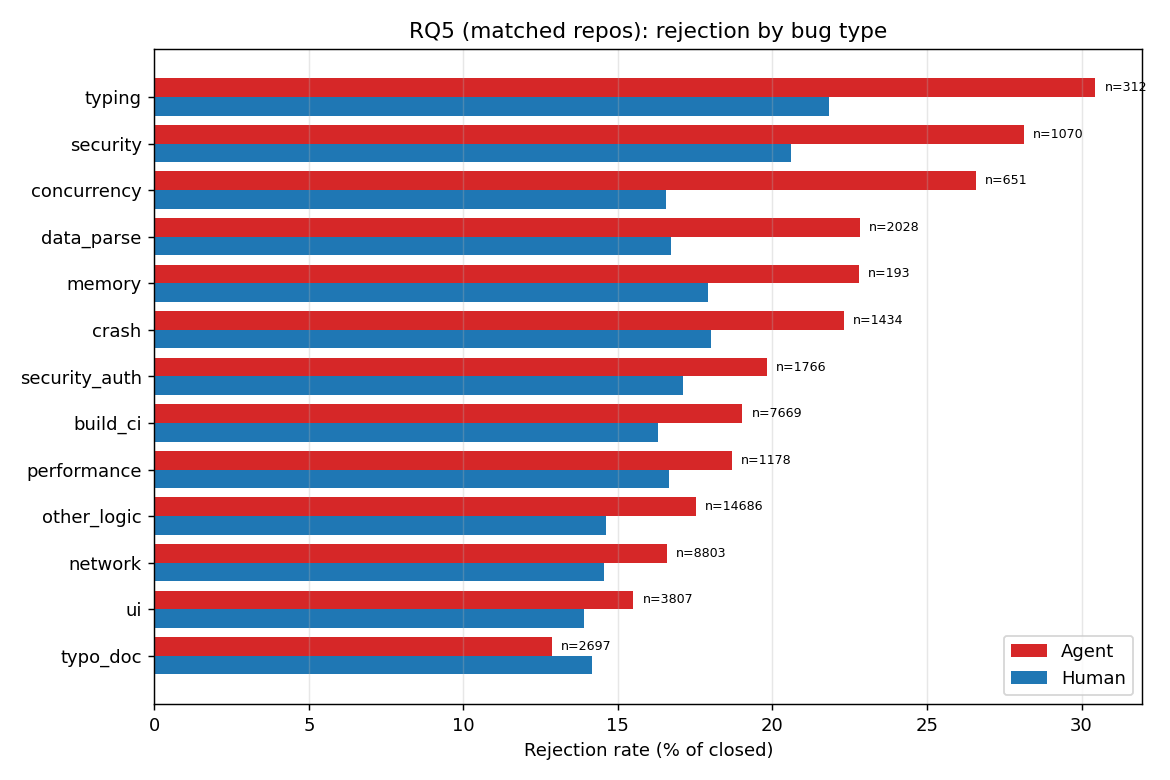

In [ ]:
meta = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"), columns=["id","title","body"])
df5 = prs.merge(meta, on="id", how="left")
df5 = df5[df5.matched]                                  # matched repos only

CATS = [
 ("security",     r"\b(security|vulnerab\w*|cve-?\d|xss|csrf|sql\s*injection|injection|exploit|sanitiz)\b"),
 ("crash",        r"\b(crash\w*|segfault|seg\s*fault|npe|null\s*pointer|nullpointer|exception|panic|fatal|stack\s*overflow)\b"),
 ("concurrency",  r"\b(race\s*condition|deadlock|concurren\w*|thread[-\s]?safe\w*|mutex|data\s*race|atomic)\b"),
 ("memory",       r"\b(memory\s*leak|mem\s*leak|out\s*of\s*memory|oom|buffer\s*overflow|leak)\b"),
 ("performance",  r"\b(performance|perf|slow\w*|latency|speed\s*up|optimi[sz]\w*|throughput|timeout)\b"),
 ("security_auth",r"\b(authenticat\w*|authoriz\w*|permission|token|login|session)\b"),
 ("ui",           r"\b(ui|ux|css|layout|render\w*|display|styling|stylesheet|button|alignment|responsive|dark\s*mode)\b"),
 ("build_ci",     r"\b(build|ci|compil\w*|lint\w*|dependenc\w*|import\s*error|module\s*not\s*found|version\s*bump|packaging)\b"),
 ("typo_doc",     r"\b(typo|spelling|grammar|docstring|readme|documentation|docs)\b"),
 ("typing",       r"\b(type\s*error|typing|type\s*hint|mypy|type\s*annotation|typescript\s*type)\b"),
 ("data_parse",   r"\b(parse|parsing|serializ\w*|deserializ\w*|json|yaml|encoding|decod\w*|formatting)\b"),
 ("network",      r"\b(http|https|api|request|response|endpoint|url|websocket|socket|connection)\b"),
]
COMP = [(n, re.compile(p, re.I)) for n, p in CATS]
def classify(t, b):
    t = t if isinstance(t, str) else ""; b = b if isinstance(b, str) else ""
    txt = f"{t} {b[:300]}"
    for n, rx in COMP:
        if rx.search(txt): return n
    return "other_logic"
df5["btype"] = [classify(t, b) for t, b in zip(df5["title"], df5["body"])]

def by_type(df):
    d = df[df["closed"]]
    t = d.groupby("btype").agg(n=("id","size"), rej=("rejected","mean"))
    t["rej"] *= 100; return t
agt = by_type(df5[df5.grp=="Agent"]).sort_values("rej", ascending=False)
agt["human_rej"] = by_type(df5[df5.grp=="Human"])["rej"]
print(agt[["n","rej","human_rej"]].assign(gap=lambda d: d.rej-d.human_rej).round(1).to_string())

order = agt.index.tolist(); y = np.arange(len(order))
plt.figure(figsize=(9,6))
plt.barh(y-0.2, agt["rej"].values, height=0.4, label="Agent", color="#d62728")
plt.barh(y+0.2, agt["human_rej"].values, height=0.4, label="Human", color="#1f77b4")
for i in range(len(order)):
    plt.text(agt["rej"].iloc[i]+0.3, i-0.2, f"n={int(agt['n'].iloc[i])}", va="center", fontsize=7)
plt.yticks(y, order); plt.gca().invert_yaxis()
plt.xlabel("Rejection rate (% of closed)"); plt.title("RQ5 (matched repos): rejection by bug type (agent vs human)")
plt.legend(); plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

## RQ6 (double-check) — Is "tests → more rejection" just because those fixes are bigger? *(matched agents)*

Fixes with tests are much bigger, and bigger fixes are harder to merge. So we compare fixes of *similar size*
and see if the test effect still shows up.

**In short: size matters, but it isn't the whole story.** Even among fixes of the same size, the agent fixes with tests
are still rejected more often. So the effect is real, not just a side-effect of size.

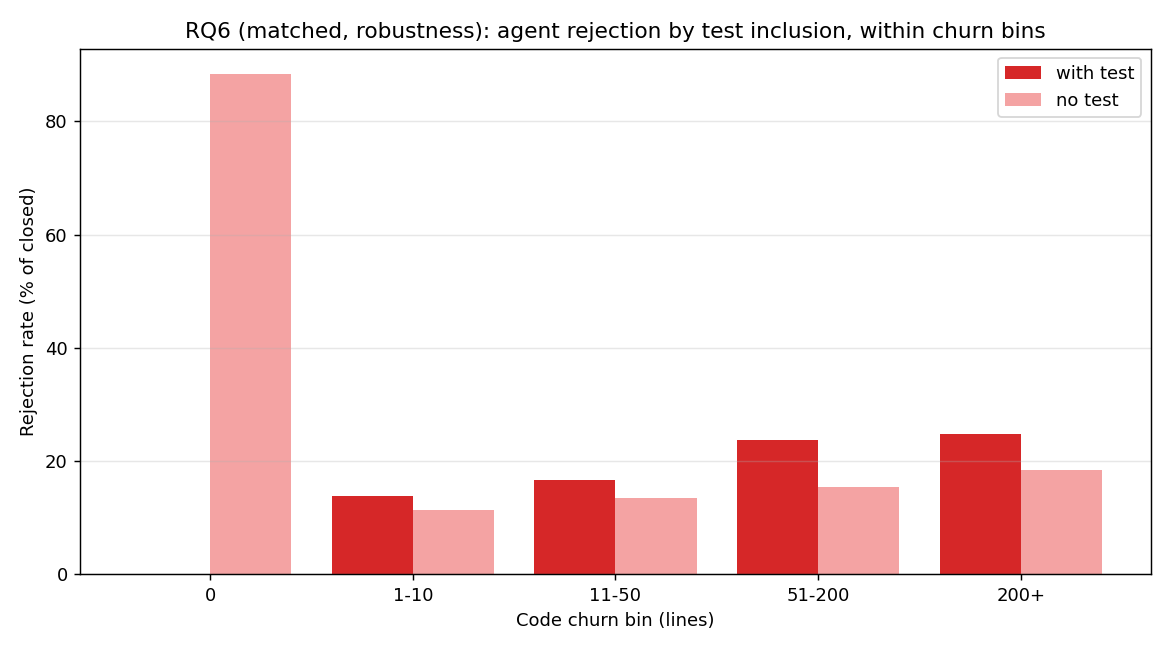

In [ ]:
a = prs[(prs.matched) & (prs.grp=="Agent") & prs["closed"]].copy()
print(f"median churn  with-test={a[a.has_test].churn.median():.0f}  no-test={a[~a.has_test].churn.median():.0f}")
bins = [-1,0,10,50,200,1e12]; lbls = ["0","1-10","11-50","51-200","200+"]
a["cb"] = pd.cut(a["churn"], bins=bins, labels=lbls)
rows = []
for b in lbls:
    sub = a[a["cb"]==b]
    rt = 100*sub[sub.has_test]["rejected"].mean(); nt = int(sub.has_test.sum())
    rn = 100*sub[~sub.has_test]["rejected"].mean(); nn = int((~sub.has_test).sum())
    rows.append((b,rt,nt,rn,nn)); print(f"churn {b:7s}: +test {rt:5.1f}% (n={nt:5d}) | no-test {rn:5.1f}% (n={nn:6d})")

x = np.arange(len(lbls))
plt.figure(figsize=(9,5))
plt.bar(x-0.2, [r[1] for r in rows], width=0.4, label="with test", color="#d62728")
plt.bar(x+0.2, [r[3] for r in rows], width=0.4, label="no test", color="#f4a3a3")
plt.xticks(x, lbls); plt.xlabel("Code churn bin (lines)"); plt.ylabel("Rejection rate (% of closed)")
plt.title("RQ6 (matched, robustness): agent rejection by test inclusion, within churn bins")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## What to keep in mind

- We compare agents and humans only inside the **1,218 repos that have both**, so the comparison is fair.
- The data is from **popular (>100-star)** repos — the same population as our MSR paper (it is seeded from AIDev's
  popular subset, `hao-li/AIDev`). So the lower overall rejection rate here (~16%) is **not** a popularity effect; it most
  likely reflects a **much larger, more recent re-collection** (121,832 agent fix PRs through Feb 2026 vs ~3,225 in the
  paper's earlier snapshot), with more settled merge outcomes. The two rates aren't directly comparable.
- A couple of measures are approximate: the "switching agents" part only sees fixes that mention an issue (~18%),
  and the revert count is a lower bound.
- The bug types (RQ5) come from keywords in the text, so they should be spot-checked by hand before publishing.

**Most solid findings:** people switch agents over time (RQ2a); inside the same projects agents are rejected a bit more
than humans (RQ1a); switching agents is rare (RQ2b); agent fixes are durable (RQ4); and agents struggle with
concurrency, type, and security bugs while matching humans on easy fixes (RQ5).